# Introduction

In the automotive sector, pricing analytics play an essential role for both companies and individuals to assess the market price of a vehicle before putting it on sale or buying it. My goal with this Data Science Project is to estimate the price of Nigerian cars by taking into account a set of features, based on historical data. I’ll be taking you through all the steps I took to achieve this objective so buckle up, it’ll only get interesting from here.



# Data
I scraped this data from cars45.com which is an online marketplace in Nigeria which connects buyers with sellers of used cars.

Firstly, let’s import the important libraries

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Now let’s import our web scraped data of Nigerian car prices

In [52]:
df = pd.read_csv("Nigerian_Car_Prices.csv")
df

,Unnamed: 0,Make,Year of manufacture,Condition,Mileage,Engine Size,Fuel,Transmission,Price,Build
0,0,Toyota,2007.0,Nigerian Used,166418.0,2400.0,Petrol,Automatic,"3,120,000",NaN
1,1,Lexus,NaN,NaN,138024.0,NaN,NaN,Automatic,"5,834,000",NaN
2,2,Mercedes-Benz,2008.0,Nigerian Used,376807.0,3000.0,Petrol,Automatic,"3,640,000",NaN
3,3,Lexus,NaN,NaN,213362.0,NaN,NaN,Automatic,"3,594,000",NaN
4,4,Mercedes-Benz,NaN,NaN,106199.0,NaN,NaN,Automatic,"8,410,000",NaN
...,...,...,...,...,...,...,...,...,...,...
4090,4090,Honda,2004.0,Nigerian Used,207446.0,3500.0,Petrol,Automatic,"1,125,000",NaN
4091,4091,Toyota,2005.0,Nigerian Used,106914.0,1800.0,Petrol,Automatic,"2,643,750",NaN
4092,4092,Honda,2006.0,Nigerian Used,247149.0,1800.0,Petrol,Automatic,"1,462,500",NaN
4093,4093,Toyota,2007.0,Nigerian Used,249325.0,2500.0,Petrol,Automatic,"2,475,000",NaN


The data consists of 4095 cars and 10 features, one of which would be the dependent variable we will predict (price).



# Methodology
EDA and data cleaning

To understand the data better and know how the numerical columns are distributed, let’s use the describe method:

In [53]:
df.describe()

,Unnamed: 0,Year of manufacture,Mileage,Engine Size
count,4095.000000,3617.000000,4.024000e+03,3584.000000
mean,2047.000000,2007.898535,1.825337e+05,3274.976562
std,1182.269005,4.300126,2.109233e+05,7693.489588
min,0.000000,1992.000000,1.000000e+00,3.000000
25%,1023.500000,2005.000000,1.020640e+05,2000.000000
50%,2047.000000,2008.000000,1.613525e+05,2500.000000
75%,3070.500000,2011.000000,2.319522e+05,3500.000000
max,4094.000000,2021.000000,9.976050e+06,371000.000000


From this, we can see that there is a large difference between the minimum and maximum values of our mileage and engine size. This indicates that there could be outliers which diminishes the effectiveness of linear models. We’ll try to rectify that later

Now let’s use the .info() method to gain more insights

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4095 entries, 0 to 4094
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           4095 non-null   int64  
 1   Make                 4095 non-null   object 
 2   Year of manufacture  3617 non-null   float64
 3   Condition            3616 non-null   object 
 4   Mileage              4024 non-null   float64
 5   Engine Size          3584 non-null   float64
 6   Fuel                 3607 non-null   object 
 7   Transmission         4075 non-null   object 
 8   Price                4095 non-null   object 
 9   Build                1127 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 320.0+ KB


The First thing we can notice is that there are missing values in some of the columns which is not a surprise to us as some people listing their cars for sale may not know some technical details of their cars such as the engine size.



But if we look closely, an issue there we can’t ignore is that the price column is seen as an object instead of an integer or float. I tried to prevent this issue when I was scraping the prices from the web by removing the naira sign, but I didn’t know that the comma would be an issue. So, let’s try to remove this by using the replace function in pandas to remove all commas. After doing that, we can now convert the column to an integer or float. I wanted to convert it to an integer because Nigerians would rather round up the price of their product to avoid the kobo currency but just to make it have the same data type as the other numerical columns, I converted it to a float

In [55]:
df["Price"].replace(to_replace=",",value="", regex=True, inplace=True )
df["Price"] = df["Price"].astype("float64")

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4095 entries, 0 to 4094
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           4095 non-null   int64  
 1   Make                 4095 non-null   object 
 2   Year of manufacture  3617 non-null   float64
 3   Condition            3616 non-null   object 
 4   Mileage              4024 non-null   float64
 5   Engine Size          3584 non-null   float64
 6   Fuel                 3607 non-null   object 
 7   Transmission         4075 non-null   object 
 8   Price                4095 non-null   float64
 9   Build                1127 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 320.0+ KB


We can now use the describe function to see the information of our data that includes the price

In [57]:
df.describe()

,Unnamed: 0,Year of manufacture,Mileage,Engine Size,Price
count,4095.000000,3617.000000,4.024000e+03,3584.000000,4.095000e+03
mean,2047.000000,2007.898535,1.825337e+05,3274.976562,4.271288e+06
std,1182.269005,4.300126,2.109233e+05,7693.489588,4.900064e+06
min,0.000000,1992.000000,1.000000e+00,3.000000,4.580000e+05
25%,1023.500000,2005.000000,1.020640e+05,2000.000000,1.872000e+06
50%,2047.000000,2008.000000,1.613525e+05,2500.000000,2.940000e+06
75%,3070.500000,2011.000000,2.319522e+05,3500.000000,4.725000e+06
max,4094.000000,2021.000000,9.976050e+06,371000.000000,5.880000e+07


From our new insights, we can see that the prices of our cars range from 458,000naira to 58,800,000naira, our mean is 4.2 million naira and our standard deviation is 4.9 million naira

Now let’s see how many missing values we have

In [58]:
df.isnull().sum()

Unnamed: 0                0
Make                      0
Year of manufacture     478
Condition               479
Mileage                  71
Engine Size             511
Fuel                    488
Transmission             20
Price                     0
Build                  2968
dtype: int64

From this, only 3 columns do not have missing values. We’ll try to rectify this issue later on but for now, let’s perform an explanatory data analysis of our features. we’ll plot the probability density functions of the continuous variable’s columns. Let’s start with the year the cars were produced

C:\Users\alexa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


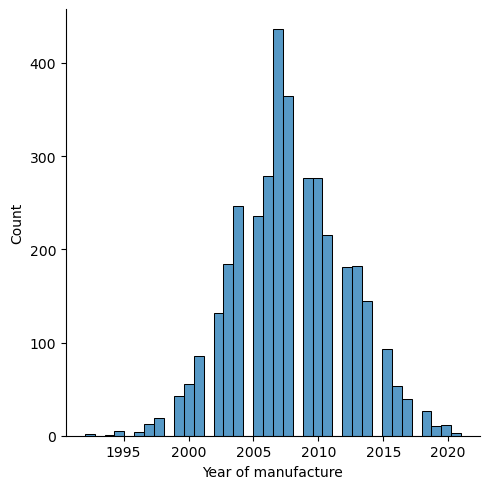

In [59]:
sns.displot(df["Year of manufacture"])

This is a normal distribution which is the most desirable distribution.

Now let’s see the PDF (Probability Density Function) of the mileage column

C:\Users\alexa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


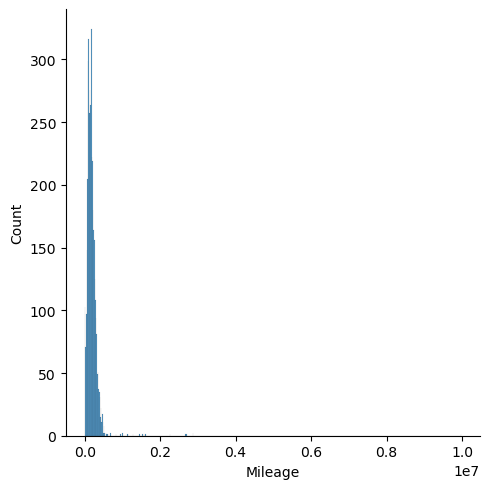

In [60]:
sns.displot(df["Mileage"])

From the PDF we observe that there are outliers in the column and it could affect the efficiency of certain machine learning models such as the ordinary least squares model which is sensitive to outliers.



Let’s try to fix this by making sure all the values fall within the 99 percentile of the ‘mileage’ variable. This way, we’ll have effectively removed the top 1% of the data about mileage

In [61]:
q = df["Mileage"].quantile(0.99)
df = df[df["Mileage"] < q]

Now let’s see the new distribution

C:\Users\alexa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


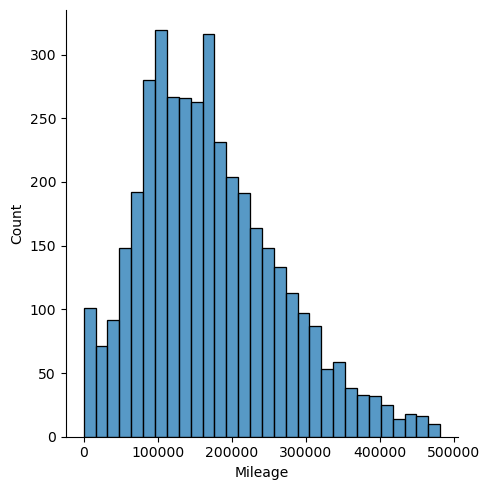

In [62]:
sns.displot(df["Mileage"])

This is much better and it now looks like a normal distribution.

Now let’s see the PDF of the Engine size

C:\Users\alexa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


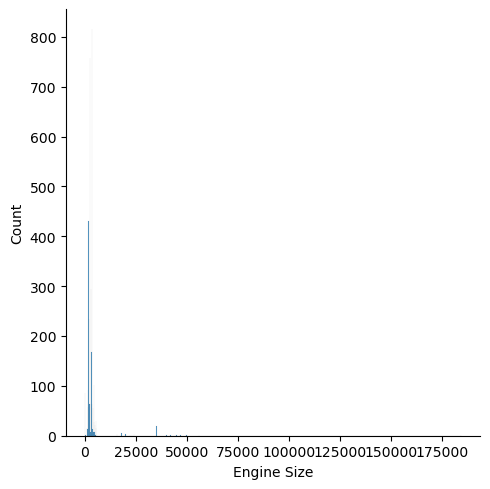

In [63]:
sns.displot(df['Engine Size'])

It is similar to the PDF of the mileage column. To try to fix this one, I checked for the biggest car engine size and I discovered that the biggest one is 8382cc and the smallest car engine size is 624cc

So, let’s remove data that are above and below those thresholds

In [64]:
df = df[df['Engine Size'] < 8382]
df = df[df['Engine Size'] > 624]

Now let’s see the PDF

C:\Users\alexa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


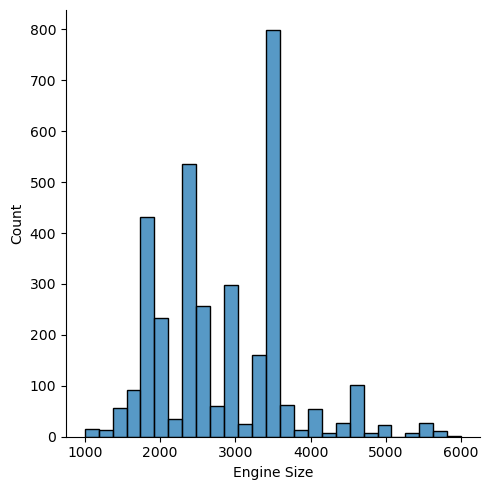

In [65]:


sns.displot(x=df['Engine Size'])

This is more desirable.

Since we’ve removed some data points, let’s see how many missing values we still have

In [66]:
df.isnull().sum()

Unnamed: 0                0
Make                      0
Year of manufacture       0
Condition                 0
Mileage                   0
Engine Size               0
Fuel                      6
Transmission              2
Price                     0
Build                  2307
dtype: int64

It has reduced significantly. It is likely that those who left a lot of empty values when listing their cars also exaggerated the values of the mileage and engine sizes

Now let’s see how the prices of the cars are related to the mileage, engine size and year manufactured

<Axes: xlabel='Engine Size', ylabel='Price'>

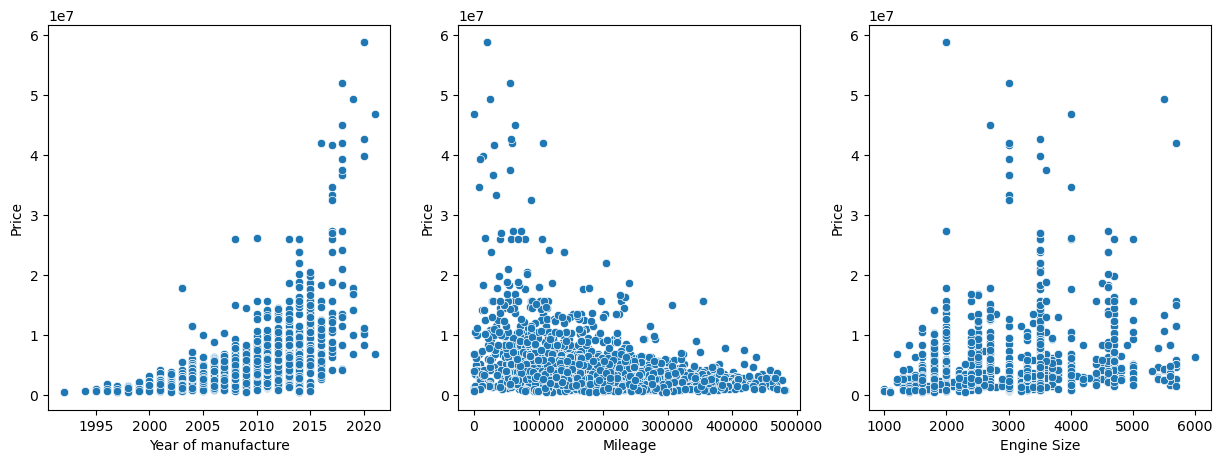

In [67]:
plt.figure(figsize=[15,5])
plt.subplot(1,3,1)
sns.scatterplot(x=df['Year of manufacture'], y=df['Price'])
plt.subplot(1,3,2)
sns.scatterplot(x=df['Mileage'], y=df['Price'])
plt.subplot(1,3,3)
sns.scatterplot(x=df['Engine Size'], y=df['Price'])

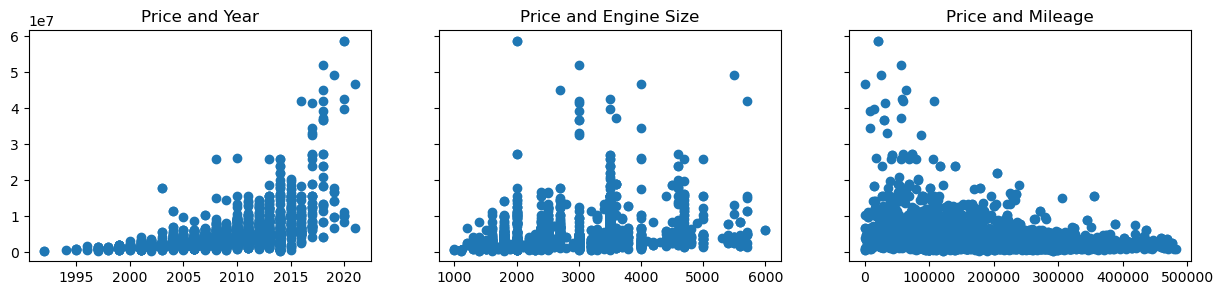

In [68]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize =(15,3))
ax1.scatter(df['Year of manufacture'],df['Price'])
ax1.set_title('Price and Year')
ax2.scatter(df['Engine Size'],df['Price'])
ax2.set_title('Price and Engine Size')
ax3.scatter(df['Mileage'],df['Price'])
ax3.set_title('Price and Mileage')
plt.show()

We can notice that cars manufactured more recently costs more than older cars, and cars with lower mileage also cost more than those with bigger mileage. But the main issue that should draw our attention here is the fact that it forms an exponential distribution



C:\Users\alexa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


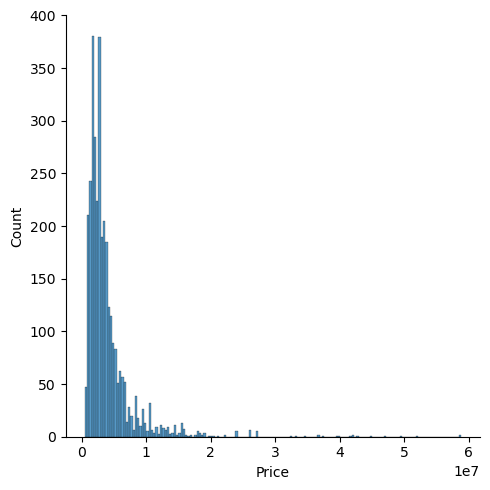

In [69]:
sns.displot(df["Price"])

The long tail makes it quite difficult for us to see the distribution, but it has an even stronger effect on a model. such distribution can greatly confuse the model, so it won’t learn well enough. One way to solve this problem is log transformation. If we apply the log function to the prices, it removes the undesired effect.

In [70]:
log_price = np.log(df['Price'])

df['log_price'] = log_price

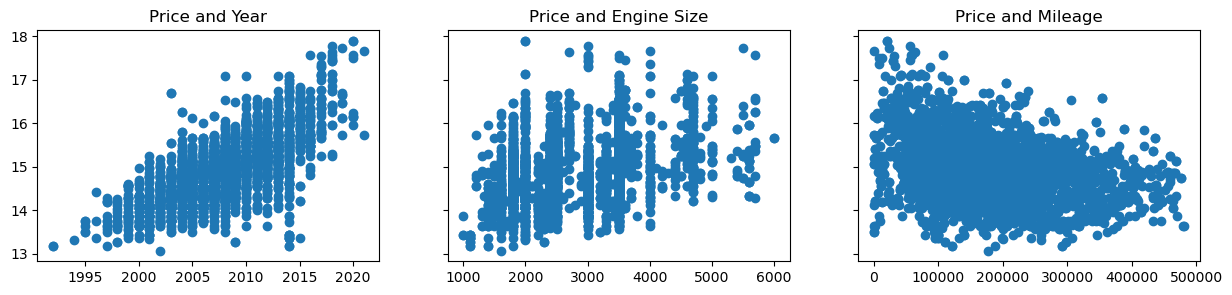

In [71]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize =(15,3)) 
ax1.scatter(df['Year of manufacture'],df['log_price'])
ax1.set_title('Price and Year')
ax2.scatter(df['Engine Size'],df['log_price'])
ax2.set_title('Price and Engine Size')
ax3.scatter(df['Mileage'],df['log_price'])
ax3.set_title('Price and Mileage')
plt.show()

C:\Users\alexa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


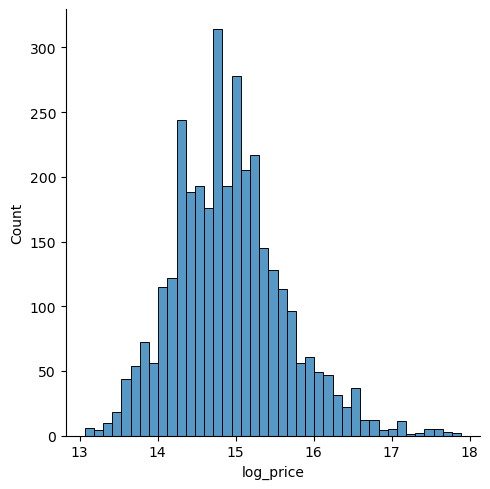

In [72]:
sns.displot(x=df['log_price'])

As we see, this transformation removes the long tail, and now the distribution resembles a bell-shaped curve. Generally, it’s good when the target distribution looks like the normal distribution. Under this condition, models such as linear regression perform well.

Now let’s visualize the categorical columns

<Axes: xlabel='Transmission', ylabel='count'>

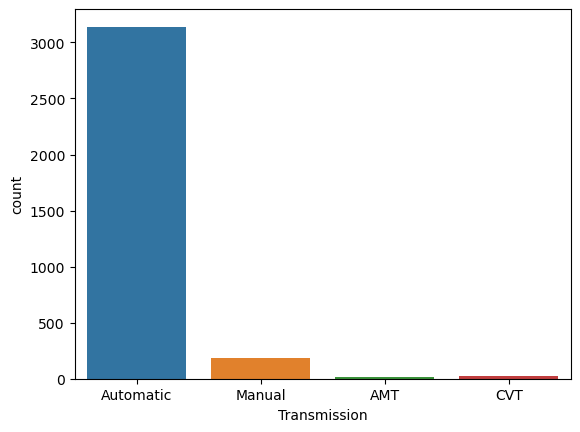

In [73]:
sns.countplot(x=df['Transmission'])

The automatic cars listed are more than the other cars listed(combined). In Nigeria, the majority of the cars are automatic except maybe pickup trucks and taxis. I didn’t know there were transmission types such as AMT (Automated Manual Transmission) and CVT (Constantly Variable Transmission) until I started this project. If you’re just like me who just learned about the CVT and AMT transmission, you should know that there’s another one that wasn’t listed on the site and it’s the DCT (Dual Clutch Transmission).

Now let’s visualize the fuel type

Press enter or click to view image in full size


<Axes: xlabel='Fuel', ylabel='count'>

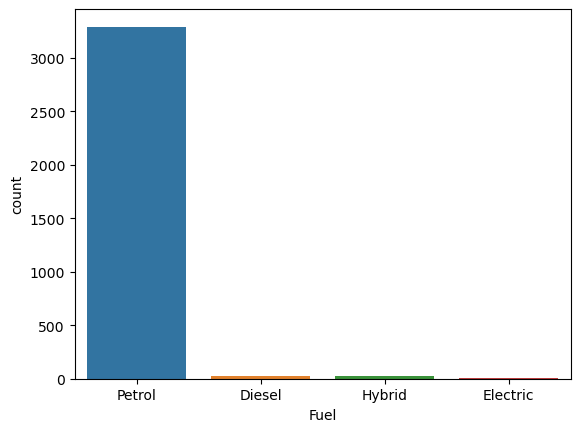

In [74]:
sns.countplot(x=df['Fuel'])

If you’re a Nigerian, this shouldn’t be a surprise to you. Diesel is way more expensive than petrol. And I’m even surprised electric cars are even listed because I haven’t physically seen an electric car charging station in Nigeria. So, it makes sense for majority of Nigerians to go for petrol cars.

<Axes: xlabel='Condition', ylabel='count'>

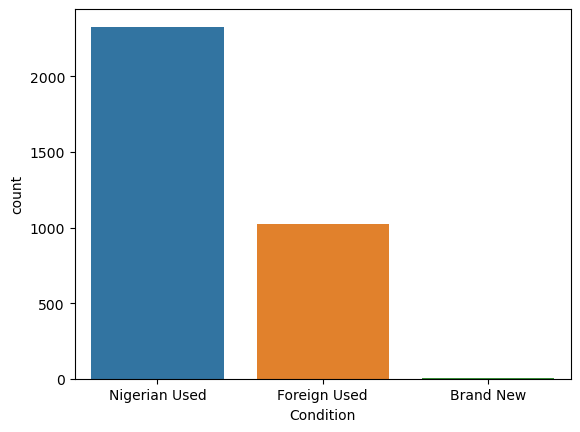

In [75]:
sns.countplot(x=df['Condition'])

It also isn’t a surprise to see that the number of brand-new cars are very few. It is because the website was designed for the sales of used cars

Now let’s see the most listed car brand and the total number of car brands on our data sets




In [76]:
df['Make'].nunique()

40

40 different brands is a lot. Although I would have liked to include that feature in the predictive model but encoding the 40 brands would make the model more complex and could be detrimental to the efficiency of the model

So, let’s drop that column and the ‘Unmarked: 0’ column which offers nothing to our dataset

In [77]:
df.drop(['Unnamed: 0','Make'], axis=1, inplace=True)

# Data Pre-processing

Now let’s prepare our data for training. We’ll start with dealing with the missing values of the Build column. I also wanted to remove that column right from when I was scraping the data but I felt that SUVs are more expensive than regular cars and it could improve the predictability of our model.

In [78]:
df['Build'] = df['Build'].fillna('other')

Now let’s define our dependent and independent variables

In [79]:
df

,Year of manufacture,Condition,Mileage,Engine Size,Fuel,Transmission,Price,Build,log_price
0,2007.0,Nigerian Used,166418.0,2400.0,Petrol,Automatic,3120000.0,other,14.953344
2,2008.0,Nigerian Used,376807.0,3000.0,Petrol,Automatic,3640000.0,other,15.107494
30,2008.0,Foreign Used,301265.0,3500.0,Petrol,Automatic,4680000.0,other,15.358809
32,2011.0,Nigerian Used,105546.0,4600.0,Petrol,Automatic,14040000.0,SUV,16.457421
43,2011.0,Foreign Used,211917.0,3500.0,Petrol,Automatic,6968000.0,other,15.756839
...,...,...,...,...,...,...,...,...,...
4090,2004.0,Nigerian Used,207446.0,3500.0,Petrol,Automatic,1125000.0,other,13.933294
4091,2005.0,Nigerian Used,106914.0,1800.0,Petrol,Automatic,2643750.0,other,14.787709
4092,2006.0,Nigerian Used,247149.0,1800.0,Petrol,Automatic,1462500.0,other,14.195658
4093,2007.0,Nigerian Used,249325.0,2500.0,Petrol,Automatic,2475000.0,other,14.721751


In [80]:
X = df.drop(['Price','log_price'], axis=1)
y = df['log_price']

In [81]:
X

,Year of manufacture,Condition,Mileage,Engine Size,Fuel,Transmission,Build
0,2007.0,Nigerian Used,166418.0,2400.0,Petrol,Automatic,other
2,2008.0,Nigerian Used,376807.0,3000.0,Petrol,Automatic,other
30,2008.0,Foreign Used,301265.0,3500.0,Petrol,Automatic,other
32,2011.0,Nigerian Used,105546.0,4600.0,Petrol,Automatic,SUV
43,2011.0,Foreign Used,211917.0,3500.0,Petrol,Automatic,other
...,...,...,...,...,...,...,...
4090,2004.0,Nigerian Used,207446.0,3500.0,Petrol,Automatic,other
4091,2005.0,Nigerian Used,106914.0,1800.0,Petrol,Automatic,other
4092,2006.0,Nigerian Used,247149.0,1800.0,Petrol,Automatic,other
4093,2007.0,Nigerian Used,249325.0,2500.0,Petrol,Automatic,other


Now to import libraries we’ll use for filling the remaining missing values, encoding the categorical columns, and scaling the numerical columns. Thereafter, we’ll split the data into the training and test set. We’ll put 80% of the data in the training set and the remaining 20% in the test.

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Let’s get our categorical and numerical columns

In [84]:
cat = [cname for cname in X.columns if X[cname].dtype == 'object']
num = [cname for cname in X.columns if X[cname].dtype == 'float64' or X[cname].dtype=='int64']


Defining our pre-processing pipeline

In [85]:
cat_pipeline = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),('encode', OneHotEncoder())])
num_pipeline = Pipeline([('scale', MinMaxScaler())])

full_pipeline = ColumnTransformer([('cat', cat_pipeline, cat), ('num', num_pipeline, num)])


prepared = full_pipeline.fit_transform(X_train)

# Training

Now we’re done with the pre-processing let’s fit a bunch of machine learning models on the training set using cross-validation and find out which one works best for our data. We’ll use the RMSE (Root Mean Squared Error) to estimate how good our model is.

In [86]:
!pip install xgboost

In [87]:
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor


models = [('sgd',SGDRegressor()),('svm',SVR()),('forest',RandomForestRegressor()),
         ('ada', AdaBoostRegressor()),('bag',BaggingRegressor()),('extree',ExtraTreesRegressor()),
          ('grad',GradientBoostingRegressor()),('xgb',XGBRegressor())]
          
for i,j in models:
    scores = cross_val_score(j, prepared, y_train, scoring='neg_mean_squared_error', cv=10)
    rmse = np.sqrt(-scores.mean())
    print(i,rmse)

sgd 0.4353831668116013
svm 0.37289738429987157
forest 0.33111533553012173
ada 0.4125855776118166
bag 0.34495136878179955
extree 0.3439398178497351
grad 0.34363009405241696
xgb 0.3332825598686924


Although not a surprise, we can see that xgboost performs the best. Although random forest comes close, we’ll still stick to xgboost.

Now let’s use grid search to try different hyperparameters to see which ones reduces the error more

In [88]:
xgb = XGBRegressor()
xgb.fit(prepared,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [89]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

xgb = XGBRegressor()
param_grid = [{'n_estimators':[100,300,400], 'max_depth':[4,5,6],'learning_rate':[0.1,0.3,0.5],
              'colsample_bylevel':[0.7,1]}]
              
grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True, 
                                   n_jobs=-1)
grid_search.fit(prepared, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid=[{'colsample_bylevel': [0.7, 1],
                          'learning_rate': [0.1, 0.3, 0.5],
                          'max_depth': [4, 5, 6],
                          'n_estimators': [100, 300, 400]}],
             return_train_score=True, scoring='neg_mean_squared_error')

Now to see the best parameters and use them when creating the xgboost object

In [90]:
grid_search.best_params_

{'colsample_bylevel': 0.7,
 'learning_rate': 0.1,
 'max_depth': 5,
 'n_estimators': 300}

In [91]:
xgb = XGBRegressor(learning_rate= 0.1, max_depth= 6, n_estimators= 300, colsample_bylevel=0.7)
xgb.fit(prepared,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.7, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

We’ve trained the model. Now to test it we have to make our test data look like the training data. Note that we would only transform the data instead of using fit transform to prevent data leakage

In [92]:
test = full_pipeline.transform(X_test)

y_pred = xgb.predict(test)


Now let’s convert our predictions back to naira and see how good our model is

In [93]:
y_test = y_test.values

In [94]:
t = np.exp(y_test)
p = np.exp(y_pred)

In [95]:
mse = mean_squared_error(p,t)
rmse = np.sqrt(mse)
print(rmse)

1728356.3825739464


An error of 1.72 million is good considering the range of our prices is from 458,000 to 58.8 million naira.

# Result

For this project, I used the Xgboost regressor to predict the prices of cars in Nigeria. It showed excellent performance by having a root mean squared error of 1.69 million naira.

Let’s look at the distribution of our predicted prices and the actual prices

C:\Users\alexa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\alexa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


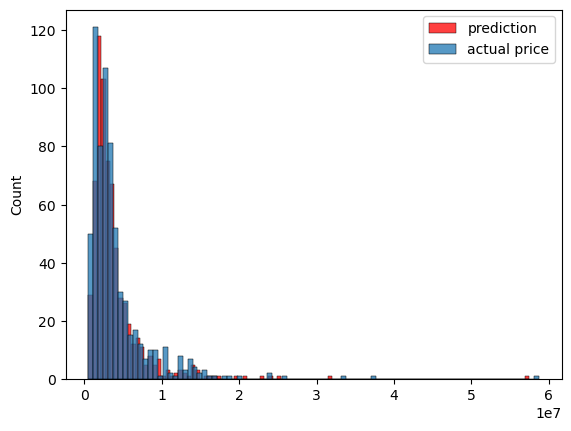

In [96]:
sns.histplot(p, label='prediction',color='red')
sns.histplot(t, label='actual price')
plt.legend()

We can see that our model was good at imitating the price.

Let’s see some of our best predictions

In [97]:
df_pred = pd.DataFrame(p, columns=['Prediction'])
df_pred['Target'] = t
df_pred['Difference%'] = np.absolute((df_pred['Target'] - df_pred['Prediction'])/df_pred['Target']*100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df_pred = df_pred.sort_values(by=['Difference%'])
df_pred

,Prediction,Target,Difference%
148,2204872.25,2205000.00,0.01
377,24146016.00,24150000.00,0.02
80,1663723.50,1664000.00,0.02
544,1574147.12,1575000.00,0.05
82,4363807.50,4368000.00,0.10
...,...,...,...
102,4947408.00,2100000.00,135.59
485,4438043.50,1785000.00,148.63
122,2439377.50,840000.00,190.40
668,20537144.00,6510000.00,215.47


With this, we can say our goal to create a model that was able to estimate the price of cars has been achieved.

# Conclusion

With this project, we have built a model that can predict the price of cars, given a set of features. This information can have an enormous value for both companies and individuals when trying to understand how to estimate the value of their vehicles.

The art of pricing is not an easy task and is sometimes only done by experts in the field, but with the study of historical data, it is possible to find patterns using machine learning that lead to results just as good. Acquiring this knowledge can provide you with a comparative advantage before putting a vehicle on sale or buying it on the market.